### 1. Imports + Setup

In [2]:
import pandas as pd
import numpy as np
import os
import glob

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### 2. Load Data

In [3]:
# World Bank Data

wb_path = "../data/world_bank_data"

wb_files = [
    f
    for f in glob.glob(os.path.join(wb_path, "*.csv"))
    if not os.path.basename(f).startswith("._")
]

print("Files found:", len(wb_files))

wb_dfs = []
for file in wb_files:
    df = pd.read_csv(file)
    df["source_file"] = os.path.basename(file)
    wb_dfs.append(df)

print("DFs created:", len(wb_dfs))

wb_df = pd.concat(wb_dfs, ignore_index=True)
wb_df = wb_df.drop(columns=["obs_status", "unit"], errors="ignore")

print("World Bank shape:", wb_df.shape)
wb_df.head()

Files found: 264
DFs created: 264
World Bank shape: (37622508, 8)


,country,country_id,indicator,indicator_id,year,value,decimal,source_file
0,Africa Eastern and Southern,ZH,Fertilizer consumption (% of fertilizer produc...,AG.CON.FERT.PT.ZS,2024,NaN,1,wb_2024_checkpoint_chunk_10.csv
1,Africa Western and Central,ZI,Fertilizer consumption (% of fertilizer produc...,AG.CON.FERT.PT.ZS,2024,NaN,1,wb_2024_checkpoint_chunk_10.csv
2,Arab World,1A,Fertilizer consumption (% of fertilizer produc...,AG.CON.FERT.PT.ZS,2024,NaN,1,wb_2024_checkpoint_chunk_10.csv
3,Caribbean small states,S3,Fertilizer consumption (% of fertilizer produc...,AG.CON.FERT.PT.ZS,2024,NaN,1,wb_2024_checkpoint_chunk_10.csv
4,Central Europe and the Baltics,B8,Fertilizer consumption (% of fertilizer produc...,AG.CON.FERT.PT.ZS,2024,NaN,1,wb_2024_checkpoint_chunk_10.csv


In [4]:
# IMF Data

imf_path = "../data/International-Monetary-Fund/imf.csv"
imf_df = pd.read_csv(imf_path)
print("IMF shape:", imf_df.shape)
imf_df.head()

IMF shape: (8208, 116)


/var/folders/vk/486jr8ts6gq8qpf704lm_ty00000gn/T/ipykernel_81719/4053711464.py:4: DtypeWarning: Columns (9,14,15,17,51,53,59) have mixed types. Specify dtype option on import or set low_memory=False.
  imf_df = pd.read_csv(imf_path)


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,DECIMALS_DISPLAYED,FUNCTIONAL_CAT,INT_ACC_ITEM,NA_STO,GFS_STO,COICOP_1999,TRADE_FLOW,COMMODITY,SOC_CONCEPTS,SECTOR,ACCOUNTING_ENTRY,INDEX_TYPE,PRICES,STATISTICAL_MEASURES,EXRATE,TRANSFORMATION,UNIT,REPORTING_PERIOD_TYPE,OVERLAP,COUNTRY_UPDATE_DATE,DOI,FULL_DESCRIPTION,AUTHOR,PUBLISHER,DEPARTMENT,CONTACT_POINT,TOPIC,TOPIC_DATASET,KEYWORDS,KEYWORDS_DATASET,LANGUAGE,PUBLICATION_DATE,UPDATE_DATE,METHODOLOGY,METHODOLOGY_NOTES,ACCESS_SHARING_LEVEL,ACCESS_SHARING_NOTES,SECURITY_CLASSIFICATION,SHORT_SOURCE_CITATION,FULL_SOURCE_CITATION,LICENSE,SUGGESTED_CITATION,KEY_INDICATOR,SERIES_NAME,LATEST_ACTUAL_ANNUAL_DATA,HISTORICAL_DATA_SOURCE,BASE_YEAR,START_END_MONTHS_OF_REPORTING_YEAR,CHAIN_WEIGHTED,BASIS_OF_PROJECTIONS,VALUATION,PRICES_SECTOR_HARMONIZED_PRICES,LABOR_SECTOR_EMPLOYMENT_TYPE,FISCAL_SECTOR_GENERAL_GOVERNMENT_COMPOSITION,FISCAL_SECTOR_VALUATION_OF_DEBT,FISCAL_SECTOR_INSTRUMENTS_INCLUDED_IN_GROSS_AND_NET_DEBT,TRADE_SECTOR_OIL_COVERAGE,PRIMARY_DOMESTIC_CURRENCY,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030
0,IMF.RES:WEO(9.0.0),LIE.LE.A,OBS_VALUE,"Liechtenstein, Principality of","Employed persons, Persons for countries / Inde...",Annual,Millions,Three,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Employed persons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Overlapping Indicator,9/29/2025,NaN,The World Economic Outlook (WEO) database cont...,NaN,International Monetary Fund (IMF),Research Department (RES),datahelp@imf.org,Employment,Economic forecasting; Balance of payments; Int...,NaN,Demographics; Real sector; Price indexes; G...,English,2025-10-14T13:00:00Z,2025-11-19T21:00:00Z,NaN,"Information on the number of employees, full-t...",Public (Unrestricted),NaN,Public or Unrestricted,IMF staff calculations.,NaN,© International Monetary Fund Copyright. All R...,International Monetary Fund. World Economic Ou...,True,"Employed persons, Persons for countries / Inde...",2024,National Statistics Office,NaN,NaN,NaN,NaN,NaN,NaN,National definition,NaN,NaN,NaN,NaN,Swiss franc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028,0.030,0.030,0.030,0.031,0.031,0.032,0.033,0.035,0.034,0.034,0.035,0.036,0.036,0.037,0.037,0.037,0.039,0.040,0.041,0.040,0.041,0.043,0.043,0.044,0.045,0.046,NaN,NaN,NaN,NaN
1,IMF.RES:WEO(9.0.0),CAN.LE.A,OBS_VALUE,Canada,"Employed persons, Persons for countries / Inde...",Annual,Millions,Three,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Employed persons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Overlapping Indicator,9/25/2025,NaN,The World Economic Outlook (WEO) database cont...,NaN,International Monetary Fund (IMF),Research Department (RES),datahelp@imf.org,Employment,Economic forecasting; Balance of payments; Int...,NaN,Demographics; Real sector; Price indexes; G...,English,2025-10-14T13:00:00Z,2025-11-19T21:00:00Z,NaN,NaN,Public (Unrestricted),NaN,Public or Unrestricted,IMF staff calculations.,NaN,© International Monetary Fund Copyright. All R...,International Monetary Fund. World Economic Ou...,True,"Employed persons, Persons for countries / Inde...",2024,National Statistics Office,NaN,NaN,NaN,NaN,NaN,NaN,National definition,NaN,NaN,NaN,NaN,Canadian dollar,10.980,11.304,10.951,11.024,11.302,11.657,12.004,12.332,12.711,12.995,13.084,12.855,12.730,12.797,13.061,13.297,13.419,13.705,14.047,14.408,14.766,14.938,15.284,15.653,15.923,16.130,16.420,16.761,16.988,16.756,16.984,17.227,17.439,17.660,17.731,17.856,17.973,18.377,18.711,19.065,18.073,18.973,19.748,20.341,20.723,21.009,21.080,NaN,NaN,NaN,NaN
2,IMF.RES:WEO(9.0.0),HND.NGDPPC.A,OBS_VALUE,Honduras,"Gross domestic product (GDP), Current prices, ...",Annual,Units,Three,NaN,NaN,Gross domestic product (GDP),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Current prices,NaN,NaN,NaN,Domestic currency,NaN,Overlapping Indicator,9/26/

In [5]:
# OECD Data

oecd_path = "../data/OECD/"
oecd_files = glob.glob(os.path.join(oecd_path, "*.csv"))

oecd_dfs = []
for file in oecd_files:
    df = pd.read_csv(file)
    df["source_file"] = os.path.basename(file)
    oecd_dfs.append(df)

oecd_df = pd.concat(oecd_dfs, ignore_index=True)
oecd_df = oecd_df.drop(columns=["obs_status", "unit"], errors="ignore")
print("OECD shape:", oecd_df.shape)
oecd_df.head()

OECD shape: (236918, 35)


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,UNIT_MEASURE,Unit of measure,ACTIVITY,Economic activity,ADJUSTMENT,Adjustment,TRANSFORMATION,Transformation,TIME_HORIZ,Time horizon,METHODOLOGY,Calculation methodology,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals,BASE_PER,Base period,source_file
0,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,HRV,Croatia,M,Monthly,BCICP,Composite business confidence,IX,Index,_Z,Not applicable,AA,Amplitude adjusted,IX,Index,_Z,Not applicable,H,OECD harmonised,2017-06,NaN,103.31430,NaN,A,Normal value,0,Units,2,Two,NaN,NaN,"OECD.SDD.STES,DSD_STES@DF_CLI,+all.csv"
1,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,CHN,China (People’s Republic of),M,Monthly,CCICP,Composite consumer confidence,IX,Index,_Z,Not applicable,AA,Amplitude adjusted,IX,Index,_Z,Not applicable,H,OECD harmonised,2023-02,NaN,96.18640,NaN,A,Normal value,0,Units,2,Two,NaN,NaN,"OECD.SDD.STES,DSD_STES@DF_CLI,+all.csv"
2,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,AUS,Australia,M,Monthly,RS,Reference series (GDP),IX,Index,_Z,Not applicable,RT,Ratio to trend,IX,Index,_Z,Not applicable,H,OECD harmonised,1969-04,NaN,99.92799,NaN,A,Normal value,0,Units,2,Two,NaN,NaN,"OECD.SDD.STES,DSD_STES@DF_CLI,+all.csv"
3,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,AUS,Australia,M,Monthly,RS,Reference series (GDP),IX,Index,_Z,Not applicable,RT,Ratio to trend,IX,Index,_Z,Not applicable,H,OECD harmonised,1969-03,NaN,99.96107,NaN,A,Normal value,0,Units,2,Two,NaN,NaN,"OECD.SDD.STES,DSD_STES@DF_CLI,+all.csv"
4,DATAFLOW,OECD.SDD.STES:DSD_STES@DF_CLI(4.1),Composite leading indicators,I,AUS,Australia,M,Monthly,RS,Reference series (GDP),IX,Index,_Z,Not applicable,RT,Ratio to trend,IX,Index,_Z,Not applicable,H,OECD harmonised,1969-02,NaN,100.06830,NaN,A,Normal value,0,Units,2,Two,NaN,NaN,"OECD.SDD.STES,DSD_STES@DF_CLI,+all.csv"


### 3. Cleaning

In [6]:
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df


wb_df = clean_columns(wb_df)
imf_df = clean_columns(imf_df)
oecd_df = clean_columns(oecd_df)

### 4.Null Analysis

In [7]:
def null_summary(df, name):
    print(f"\n{name} NULL SUMMARY")
    nulls = df.isnull().sum()
    pct = (nulls / len(df)) * 100

    summary = pd.DataFrame({"null_count": nulls, "null_pct": pct}).sort_values(
        by="null_pct", ascending=False
    )

    return summary


wb_nulls = null_summary(wb_df, "World Bank")
imf_nulls = null_summary(imf_df, "IMF")
oecd_nulls = null_summary(oecd_df, "OECD")

wb_nulls.head(10)


World Bank NULL SUMMARY

IMF NULL SUMMARY

OECD NULL SUMMARY


,null_count,null_pct
value,25748018,68.437803
country_id,141438,0.375940
country,0,0.000000
indicator,0,0.000000
indicator_id,0,0.000000
year,0,0.000000
decimal,0,0.000000
source_file,0,0.000000


### 5. Basic EDA

In [8]:
print("WB:", wb_df.shape)
print("IMF:", imf_df.shape)
print("OECD:", oecd_df.shape)

WB: (37622508, 8)
IMF: (8208, 116)
OECD: (236918, 35)


In [9]:
wb_df.dtypes

country          object
country_id       object
indicator        object
indicator_id     object
year              int64
value           float64
decimal           int64
source_file      object
dtype: object

In [10]:
wb_df.describe()

,year,value,decimal
count,3.762251e+07,1.187449e+07,3.762251e+07
mean,1.992500e+03,6.560077e+15,5.081661e-01
std,1.905037e+01,1.103306e+19,5.834900e-01
min,1.960000e+03,-1.067341e+16,0.000000e+00
25%,1.976000e+03,7.647530e+00,0.000000e+00
50%,1.992500e+03,2.040000e+02,0.000000e+00
75%,2.009000e+03,1.439734e+08,1.000000e+00
max,2.025000e+03,2.435800e+22,2.000000e+00


In [11]:
wb_df["country"].nunique()
wb_df["year"].nunique()

66

In [14]:
wb_df.columns.tolist()
wb_df["value"] = pd.to_numeric(wb_df["value"], errors="coerce")
wb_df["indicator"].drop_duplicates().sample(20)

438102              GNI, PPP (constant 2021 international $)
32718                  Net ODA provided, total (current US$)
93898           Subsidies and other transfers (% of expense)
57988      Electricity production from oil, gas and coal ...
408044              Imports of goods and services (% of GDP)
28462      Net bilateral aid flows from DAC donors, Japan...
102144     B-READY: Business Location Pillar 3: Operation...
93632            Subsidies and other transfers (current LCU)
25270      Net bilateral aid flows from DAC donors, Germa...
414428     Industry (including construction), value added...
2055116    Coverage of social protection and labor progra...
107198     B-READY: Market Competition Pillar 2: Public S...
434112     GDP per capita, PPP (constant 2021 internation...
115976     Firms with female participation in ownership (...
406182                Gross capital formation (constant LCU)
72618            Total reserves (includes gold, current US$)
34048                   

In [24]:
gdp_df = wb_df[wb_df["indicator"].str.contains("GDP", case=False, na=False)]
inflation_df = wb_df[wb_df["indicator"].str.contains("inflation", case=False, na=False)]
unemp_df = wb_df[wb_df["indicator"].str.contains("unemployment", case=False, na=False)]

gdp_df.head()

,country,country_id,indicator,indicator_id,year,value,decimal,source_file
7182,Africa Eastern and Southern,ZH,Trade in services (% of GDP),BG.GSR.NFSV.GD.ZS,2024,10.733715,1,wb_2024_checkpoint_chunk_10.csv
7183,Africa Western and Central,ZI,Trade in services (% of GDP),BG.GSR.NFSV.GD.ZS,2024,NaN,1,wb_2024_checkpoint_chunk_10.csv
7184,Arab World,1A,Trade in services (% of GDP),BG.GSR.NFSV.GD.ZS,2024,23.346796,1,wb_2024_checkpoint_chunk_10.csv
7185,Caribbean small states,S3,Trade in services (% of GDP),BG.GSR.NFSV.GD.ZS,2024,NaN,1,wb_2024_checkpoint_chunk_10.csv
7186,Central Europe and the Baltics,B8,Trade in services (% of GDP),BG.GSR.NFSV.GD.ZS,2024,24.332612,1,wb_2024_checkpoint_chunk_10.csv


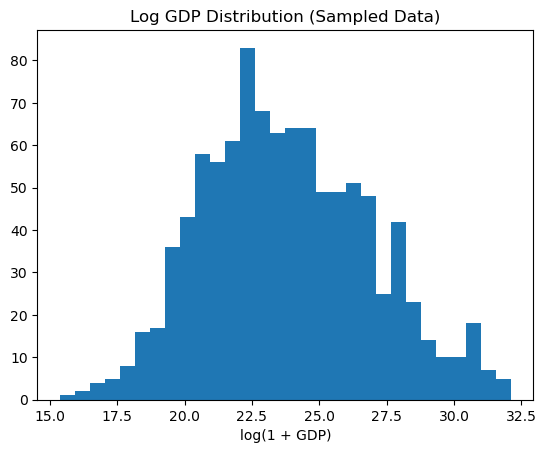

In [ ]:
gdp_df = wb_df[wb_df["indicator_id"] == "NY.GDP.MKTP.CD"].copy()
gdp_df["value"] = pd.to_numeric(gdp_df["value"], errors="coerce")

vals = gdp_df["value"].dropna().sample(1000, random_state=42)

plt.hist(np.log1p(vals), bins=30)
plt.title("Log GDP Distribution (Sampled Data)")
plt.xlabel("log(1 + GDP)")
plt.show()

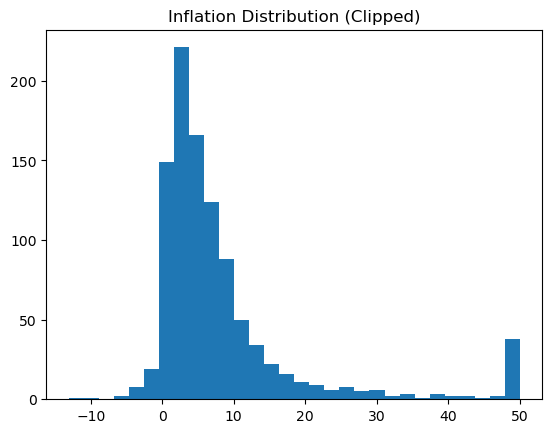

In [37]:
inflation_vals = inflation_df["value"].dropna()

# clip to reasonable range
inflation_vals_clipped = inflation_vals.clip(-20, 50)

plt.hist(inflation_vals_clipped.sample(1000, random_state=42), bins=30)
plt.title("Inflation Distribution (Clipped)")
plt.show()

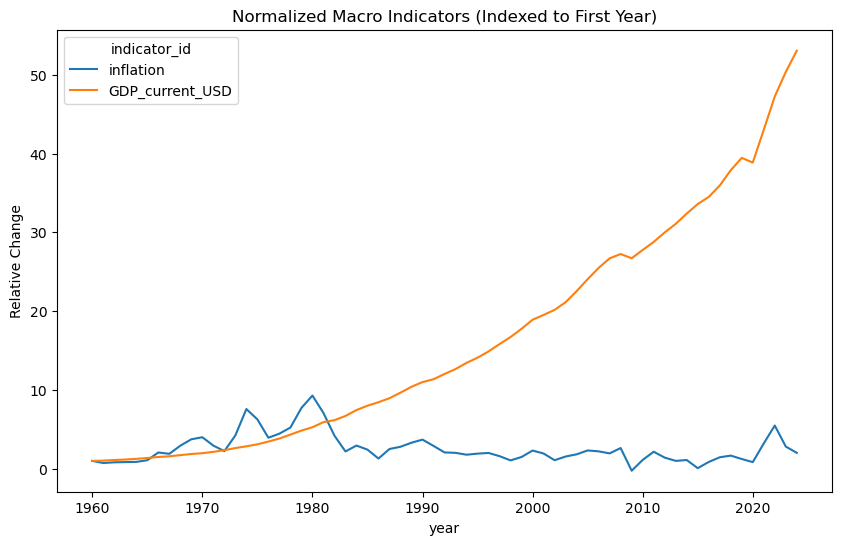

In [ ]:
country_name = "United States"

us_macro = wb_df[
    (wb_df["country"] == country_name)
    & (
        wb_df["indicator_id"].isin(
            ["NY.GDP.MKTP.CD", "FP.CPI.TOTL.ZG", "SL.UEM.TOTL.ZS"]
        )
    )
].copy()

us_macro["value"] = pd.to_numeric(us_macro["value"], errors="coerce")

pivot_df = us_macro.pivot_table(index="year", columns="indicator_id", values="value")

pivot_df = pivot_df.rename(
    columns={
        "NY.GDP.MKTP.CD": "GDP_current_USD",
        "FP.CPI.TOTL.ZG": "inflation",
        "SL.UEM.TOTL.ZS": "unemployment",
    }
)

normalized = pivot_df / pivot_df.iloc[0]

normalized.plot(figsize=(10, 6))
plt.title("Normalized Macro Indicators (Indexed to First Year)")
plt.ylabel("Relative Change")
plt.show()